In [9]:
import pandas as pd
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [10]:
X_train = pd.read_csv("../data/processed/X_train_smote.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train_smote.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(X_train.shape)
print(X_test.shape)

(453204, 31)
(56746, 31)


In [12]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_estimators=300
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        n_estimators=300
    )
}

In [13]:
results = []

trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, probabilities)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })

    trained_models[name] = model

    print(classification_report(y_test, predictions))


Training Logistic Regression...
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746


Training Random Forest...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.74      0.81        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746


Training XGBoost...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.83      0.80      0.81        95

    accuracy                           1.00     56746
   macro avg       0.91      0.90      0.91    

In [15]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
2              XGBoost  0.999383   0.826087  0.800000  0.812834  0.977918
1        Random Forest  0.999436   0.909091  0.736842  0.813953  0.973788
3             LightGBM  0.999383   0.848837  0.768421  0.806630  0.961696
0  Logistic Regression  0.973373   0.052465  0.873684  0.098986  0.959227


In [16]:
results_df.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

In [17]:
joblib.dump(
    trained_models["Logistic Regression"],
    "../models/logistic_regression.pkl"
)

joblib.dump(
    trained_models["Random Forest"],
    "../models/random_forest.pkl"
)

joblib.dump(
    trained_models["XGBoost"],
    "../models/xgboost.pkl"
)

joblib.dump(
    trained_models["LightGBM"],
    "../models/lightgbm.pkl"
)

['../models/lightgbm.pkl']

In [18]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

print(f"Best Model: {best_model_name}")

Best Model: XGBoost


In [19]:
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
2              XGBoost  0.999383   0.826087  0.800000  0.812834  0.977918
1        Random Forest  0.999436   0.909091  0.736842  0.813953  0.973788
3             LightGBM  0.999383   0.848837  0.768421  0.806630  0.961696
0  Logistic Regression  0.973373   0.052465  0.873684  0.098986  0.959227


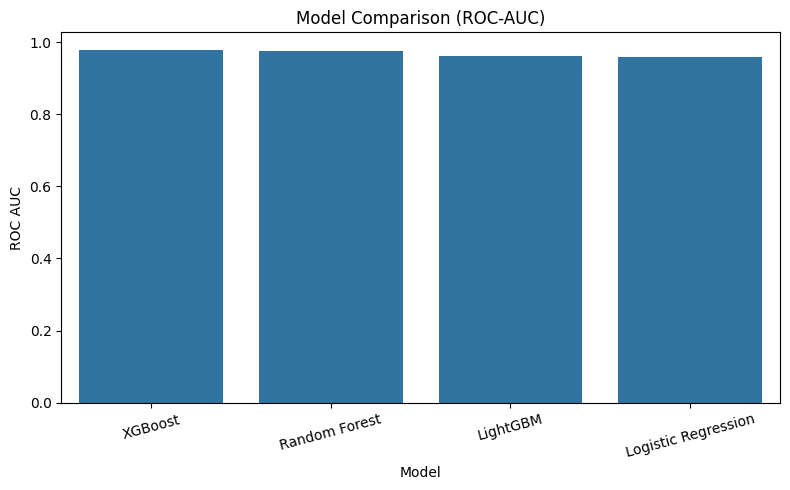

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC AUC"
)

plt.title("Model Comparison (ROC-AUC)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../images/model_comparison.png",
    dpi=300
)

plt.show()